In [22]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import display



In [23]:

folder_path = "../ingestion/data/backup/temp_transcripts.parquet"
df_tx = pl.read_parquet(folder_path)

print(f"Rows: {df_tx.height:,}")
print(f"Columns: {df_tx.width}")
print(f"Symbols: {df_tx.get_column('symbol').n_unique():,}")
print(
    f"Fiscal date range: {df_tx.select(pl.min('fiscalDateEnding')).item()} to {df_tx.select(pl.max('fiscalDateEnding')).item()}"
)
print(
    f"Reported date range: {df_tx.select(pl.min('reportedDate')).item()} to {df_tx.select(pl.max('reportedDate')).item()}"
)
df_tx.glimpse()

Rows: 23,313
Columns: 13
Symbols: 500
Fiscal date range: 2013-11-30 to 2026-04-30
Reported date range: 2014-01-07 to 2026-05-28
Rows: 23313
Columns: 13
$ fiscalDateEnding              <date> 2023-09-30, 2016-06-30, 2013-12-31, 2015-01-31, 2016-06-30, 2015-09-30, 2022-03-31, 2016-06-30, 2016-03-31, 2016-03-31
$ reportedDate                  <date> 2023-10-27, 2016-08-05, 2014-02-04, 2015-03-05, 2016-07-28, 2015-10-29, 2022-05-05, 2016-07-28, 2016-05-05, 2016-04-26
$ reportedEPS                    <str> '2.95', '0.87', '0.88', '0.44', '0.85', '3.31', '5.83', '0.77', '0.89', '0.44'
$ estimatedEPS                   <str> '2.87', '0.82', '0.83', '0.39', '0.97', '2.99', '6.04', '0.72', '0.85', '0.41'
$ surprise                       <str> '0.08', '0.05', '0.05', '0.05', '-0.12', '0.32', '-0.21', '0.05', '0.04', '0.03'
$ surprisePercentage             <str> '2.7875', '6.0976', '6.0241', '12.8205', '-12.3711', '10.7023', '-3.4768', '6.9444', '4.7059', '7.3171'
$ reportTime                     

In [21]:
numeric_eps = df_tx.with_columns(
    [
        pl.col("reportedEPS").cast(pl.Float64, strict=False).alias("reportedEPS_num"),
        pl.col("estimatedEPS").cast(pl.Float64, strict=False).alias("estimatedEPS_num"),
        pl.col("surprise").cast(pl.Float64, strict=False).alias("surprise_num"),
        pl.col("surprisePercentage").cast(pl.Float64, strict=False).alias("surprise_pct_num"),
        pl.col("transcript").list.len().alias("turn_count"),
    ]
)

overview = pl.DataFrame(
    {
        "metric": [
            "quarter rows",
            "unique symbols",
            "quarters with no transcript turns",
            "avg transcript turns per quarter",
            "median transcript turns per quarter",
            "min transcript turns per quarter",
            "max transcript turns per quarter",
        ],
        "value": [
            f"{numeric_eps.height:,}",
            f"{numeric_eps.get_column('symbol').n_unique():,}",
            f"{numeric_eps.filter(pl.col('turn_count') == 0).height:,}",
            f"{numeric_eps.select(pl.mean('turn_count')).item():.2f}",
            f"{numeric_eps.select(pl.median('turn_count')).item():.2f}",
            f"{numeric_eps.select(pl.min('turn_count')).item():.0f}",
            f"{numeric_eps.select(pl.max('turn_count')).item():.0f}",
        ],
    }
)

overview

metric,value
str,str
"""quarter rows""","""23,313"""
"""unique symbols""","""500"""
"""quarters with no transcript tu…","""209"""
"""avg transcript turns per quart…","""65.68"""
"""median transcript turns per qu…","""63.00"""
"""min transcript turns per quart…","""0"""
"""max transcript turns per quart…","""251"""


In [9]:
tx_turns = (
    numeric_eps.select(
        [
            "fiscalDateEnding",
            "reportedDate",
            "reportedEPS",
            "estimatedEPS",
            "surprise",
            "surprisePercentage",
            "reportTime",
            "symbol",
            "fiscal_month",
            "fiscal_year",
            "av_quarter",
            "time_from",
            "turn_count",
            pl.col("transcript"),
        ]
    )
    .explode("transcript")
    .unnest("transcript")
    .with_columns(
        [
            pl.col("speaker").fill_null("Unknown").str.strip_chars().alias("speaker"),
            pl.col("title").fill_null("Unknown").str.strip_chars().alias("title"),
            pl.col("sentiment").fill_null("Unknown").str.strip_chars().alias("sentiment"),
            pl.col("content").fill_null("").str.strip_chars().alias("content"),
        ]
    )
    .with_columns(
        [
            pl.col("content").str.len_chars().alias("content_chars"),
            pl.col("content").str.count_matches(r"\S+").alias("content_words"),
        ]
    )
)

tx_turns.head(10)

fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol,fiscal_month,fiscal_year,av_quarter,time_from,turn_count,speaker,title,content,sentiment,content_chars,content_words
date,date,str,str,str,str,str,str,i8,i32,str,str,u32,str,str,str,str,u32,u32
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Tejas Gala""","""Director of Investor Relations…","""Thank you. Good afternoon, and…","""0.5""",1129,174
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Tim Cook""","""CEO""","""Thank you, Tejas. Good afterno…","""0.7""",9275,1519
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Luca Maestri""","""CFO""","""Thank you, Tim, and good after…","""0.6""",7487,1140
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Tejas Gala""","""Director of Investor Relations…","""Thank you, Luca. Operator, may…","""0.5""",66,11
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Operator""","""Operator""","""We'll take our first question …","""0.0""",64,10
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Amit Daryanani""","""Analyst""","""I guess two from my side. Mayb…","""0.1""",420,74
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Luca Maestri""","""CFO""","""Yes, Amit. We're guiding 41.5%…","""0.2""",582,105
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Amit Daryanani""","""Analyst""","""Fair enough. And then if I cou…","""0.0""",496,82
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""","""AAPL""",9,2022,"""2022Q3""","""20221027T0000""",59,"""Tim Cook""","""CEO""","""Thank you for the question. I’…","""0.4""",885,136


In [15]:
df_tx.schema , df_tx.shape

(Schema([('fiscalDateEnding', Date),
         ('reportedDate', Date),
         ('reportedEPS', String),
         ('estimatedEPS', String),
         ('surprise', String),
         ('surprisePercentage', String),
         ('reportTime', String),
         ('symbol', String),
         ('fiscal_month', Int8),
         ('fiscal_year', Int32),
         ('av_quarter', String),
         ('time_from', String),
         ('transcript',
          List(Struct({'speaker': String, 'title': String, 'content': String, 'sentiment': String})))]),
 (20653, 13))

In [18]:
tx_turns.schema , tx_turns.shape

(Schema([('fiscalDateEnding', Date),
         ('reportedDate', Date),
         ('reportedEPS', String),
         ('estimatedEPS', String),
         ('surprise', String),
         ('surprisePercentage', String),
         ('reportTime', String),
         ('symbol', String),
         ('fiscal_month', Int8),
         ('fiscal_year', Int32),
         ('av_quarter', String),
         ('time_from', String),
         ('turn_count', UInt32),
         ('speaker', String),
         ('title', String),
         ('content', String),
         ('sentiment', String),
         ('content_chars', UInt32),
         ('content_words', UInt32)]),
 (1337186, 19))

In [10]:


tx_turns_scored = tx_turns.with_columns(
    [pl.col("sentiment").cast(pl.Float64, strict=False).alias("sentiment_score")]
)

In [11]:


turn_summary = pl.DataFrame(
    {
        "metric": [
            "turn rows",
            "unique speakers",
            "unique titles",
            "rows with numeric sentiment scores",
            "avg words per turn",
            "median words per turn",
            "max words in a turn",
        ],
        "value": [
            f"{tx_turns_scored.height:,}",
            f"{tx_turns_scored.get_column('speaker').n_unique():,}",
            f"{tx_turns_scored.get_column('title').n_unique():,}",
            f"{tx_turns_scored.select(pl.col('sentiment_score').is_not_null().sum()).item():,}",
            f"{tx_turns_scored.select(pl.mean('content_words')).item():.2f}",
            f"{tx_turns_scored.select(pl.median('content_words')).item():.2f}",
            f"{tx_turns_scored.select(pl.max('content_words')).item():.0f}",
        ],
    }
)

speaker_counts = (
    tx_turns_scored.group_by("speaker")
    .agg(pl.len().alias("turns"))
    .sort("turns", descending=True)
    .head(15)
)

sentiment_stats = tx_turns_scored.select(
    [
        pl.mean("sentiment_score").alias("mean_sentiment"),
        pl.median("sentiment_score").alias("median_sentiment"),
        pl.min("sentiment_score").alias("min_sentiment"),
        pl.max("sentiment_score").alias("max_sentiment"),
        pl.col("sentiment_score").null_count().alias("null_sentiment_scores"),
    ]
)

report_time_counts = (
    numeric_eps.group_by("reportTime")
    .agg(pl.len().alias("quarters"))
    .sort("quarters", descending=True)
)

display(turn_summary)
display(sentiment_stats)
display(speaker_counts)
display(report_time_counts)

metric,value
str,str
"""turn rows""","""1,337,186"""
"""unique speakers""","""20,650"""
"""unique titles""","""10,083"""
"""rows with numeric sentiment sc…","""1,336,896"""
"""avg words per turn""","""116.52"""
"""median words per turn""","""56.00"""
"""max words in a turn""","""7016"""


mean_sentiment,median_sentiment,min_sentiment,max_sentiment,null_sentiment_scores
f64,f64,f64,f64,u32
0.216673,0.1,-0.8,1.0,290


speaker,turns
str,u32
"""Operator""",212055
"""Unidentified Analyst""",4683
"""Julien Dumoulin-Smith""",2956
"""Betsy Graseck""",1685
"""Paul Patterson""",1631
…,…
"""Julian Mitchell""",1479
"""David Simon""",1437
"""Jeremy Tonet""",1414


reportTime,quarters
str,u32
"""pre-market""",12240
"""post-market""",8413


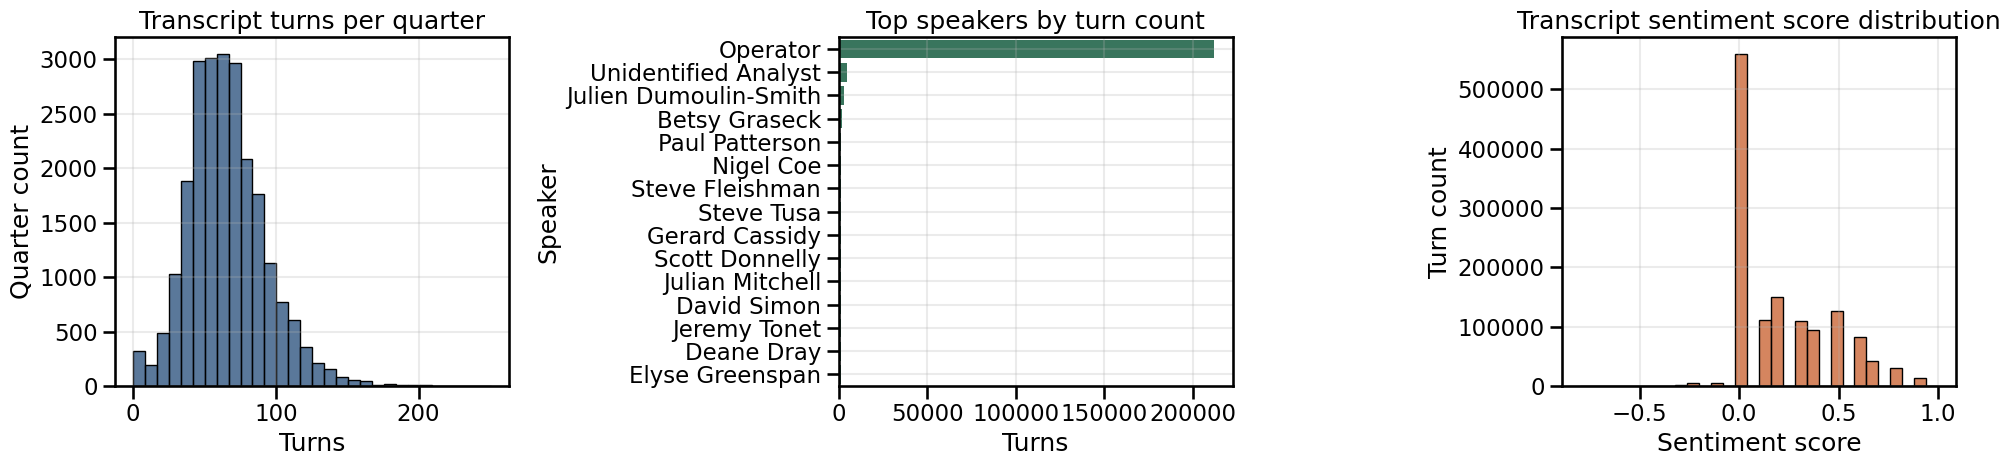

In [25]:
quarter_turn_counts = numeric_eps.select(pl.col("turn_count")).to_series().to_list()
sentiment_scores = tx_turns_scored.drop_nulls("sentiment_score").select(pl.col("sentiment_score")).to_series().to_list()

speaker_plot = speaker_counts.to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(quarter_turn_counts, bins=30, color="#234b78", ax=axes[0])
axes[0].set_title("Transcript turns per quarter")
axes[0].set_xlabel("Turns")
axes[0].set_ylabel("Quarter count")

sns.barplot(data=speaker_plot, x="turns", y="speaker", ax=axes[1], color="#2f7f5f")
axes[1].set_title("Top speakers by turn count")
axes[1].set_xlabel("Turns")
axes[1].set_ylabel("Speaker")

sns.histplot(sentiment_scores, bins=30, color="#c75c2a", ax=axes[2])
axes[2].set_title("Transcript sentiment score distribution")
axes[2].set_xlabel("Sentiment score")
axes[2].set_ylabel("Turn count")

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()

In [ ]:


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pl.Config.set_tbl_rows(10)
pl.Config.set_tbl_cols(14)

polars.config.Config

In [13]:
folder_path = "../ingestion/data/backup/temp_transcripts.parquet"
df_tx = pl.read_parquet(folder_path)

print(f"Rows: {df_tx.height:,}")
print(f"Columns: {df_tx.width}")
print(f"Symbols: {df_tx.get_column('symbol').n_unique():,}")
print(
    f"Fiscal date range: {df_tx.select(pl.min('fiscalDateEnding')).item()} to {df_tx.select(pl.max('fiscalDateEnding')).item()}"
)
print(
    f"Reported date range: {df_tx.select(pl.min('reportedDate')).item()} to {df_tx.select(pl.max('reportedDate')).item()}"
)


Rows: 20,653
Columns: 13
Symbols: 500
Fiscal date range: 2013-11-30 to 2026-04-30
Reported date range: 2014-01-07 to 2026-05-28


In [20]:
## Transcript EDA overview

# Each row represents one earnings quarter for a symbol. The transcript column is a nested list of speaker turns, so the first step is to summarize the quarter-level dataset and then explode the transcript into turn-level records for text analysis.

In [21]:
numeric_eps = df_tx.with_columns(
    [
        pl.col("reportedEPS").cast(pl.Float64, strict=False).alias("reportedEPS_num"),
        pl.col("estimatedEPS").cast(pl.Float64, strict=False).alias("estimatedEPS_num"),
        pl.col("surprise").cast(pl.Float64, strict=False).alias("surprise_num"),
        pl.col("surprisePercentage").cast(pl.Float64, strict=False).alias("surprise_pct_num"),
        pl.col("transcript").list.len().alias("turn_count"),
    ]
)

overview = pl.DataFrame(
    {
        "metric": [
            "quarter rows",
            "unique symbols",
            "quarters with no transcript turns",
            "avg transcript turns per quarter",
            "median transcript turns per quarter",
            "min transcript turns per quarter",
            "max transcript turns per quarter",
        ],
        "value": [
            f"{numeric_eps.height:,}",
            f"{numeric_eps.get_column('symbol').n_unique():,}",
            f"{numeric_eps.filter(pl.col('turn_count') == 0).height:,}",
            f"{numeric_eps.select(pl.mean('turn_count')).item():.2f}",
            f"{numeric_eps.select(pl.median('turn_count')).item():.2f}",
            f"{numeric_eps.select(pl.min('turn_count')).item():.0f}",
            f"{numeric_eps.select(pl.max('turn_count')).item():.0f}",
        ],
    }
)

overview

metric,value
str,str
"""quarter rows""","""20,653"""
"""unique symbols""","""500"""
"""quarters with no transcript tu…","""209"""
"""avg transcript turns per quart…","""64.99"""
"""median transcript turns per qu…","""62.00"""
"""min transcript turns per quart…","""0"""
"""max transcript turns per quart…","""251"""


In [22]:
tx_turns = (
    numeric_eps.select(
        [
            "fiscalDateEnding",
            "reportedDate",
            "reportedEPS",
            "estimatedEPS",
            "surprise",
            "surprisePercentage",
            "reportTime",
            "symbol",
            "fiscal_month",
            "fiscal_year",
            "av_quarter",
            "time_from",
            "turn_count",
            pl.col("transcript"),
        ]
    )
    .explode("transcript")
    .unnest("transcript")
    .with_columns(
        [
            pl.col("speaker").fill_null("Unknown").str.strip_chars().alias("speaker"),
            pl.col("title").fill_null("Unknown").str.strip_chars().alias("title"),
            pl.col("sentiment").fill_null("Unknown").str.strip_chars().alias("sentiment"),
            pl.col("content").fill_null("").str.strip_chars().alias("content"),
        ]
    )
    .with_columns(
        [
            pl.col("content").str.len_chars().alias("content_chars"),
            pl.col("content").str.count_matches(r"\S+").alias("content_words"),
        ]
    )
)

tx_turns.head(10)

fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,…,turn_count,speaker,title,content,sentiment,content_chars,content_words
date,date,str,str,str,str,str,…,u32,str,str,str,str,u32,u32
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Tejas Gala""","""Director of Investor Relations…","""Thank you. Good afternoon, and…","""0.5""",1129,174
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Tim Cook""","""CEO""","""Thank you, Tejas. Good afterno…","""0.7""",9275,1519
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Luca Maestri""","""CFO""","""Thank you, Tim, and good after…","""0.6""",7487,1140
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Tejas Gala""","""Director of Investor Relations…","""Thank you, Luca. Operator, may…","""0.5""",66,11
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Operator""","""Operator""","""We'll take our first question …","""0.0""",64,10
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Amit Daryanani""","""Analyst""","""I guess two from my side. Mayb…","""0.1""",420,74
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Luca Maestri""","""CFO""","""Yes, Amit. We're guiding 41.5%…","""0.2""",582,105
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Amit Daryanani""","""Analyst""","""Fair enough. And then if I cou…","""0.0""",496,82
2022-09-30,2022-10-27,"""1.29""","""1.27""","""0.02""","""1.5748""","""post-market""",…,59,"""Tim Cook""","""CEO""","""Thank you for the question. I’…","""0.4""",885,136


In [23]:
quarter_turn_counts = numeric_eps.select(pl.col("turn_count")).to_series().to_list()
sentiment_scores = tx_turns_scored.drop_nulls("sentiment_score").select(pl.col("sentiment_score")).to_series().to_list()

speaker_plot = speaker_counts.to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(quarter_turn_counts, bins=30, color="#234b78", ax=axes[0])
axes[0].set_title("Transcript turns per quarter")
axes[0].set_xlabel("Turns")
axes[0].set_ylabel("Quarter count")

sns.barplot(data=speaker_plot, x="turns", y="speaker", ax=axes[1], color="#2f7f5f")
axes[1].set_title("Top speakers by turn count")
axes[1].set_xlabel("Turns")
axes[1].set_ylabel("Speaker")

sns.histplot(sentiment_scores, bins=30, color="#c75c2a", ax=axes[2])
axes[2].set_title("Transcript sentiment score distribution")
axes[2].set_xlabel("Sentiment score")
axes[2].set_ylabel("Turn count")

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()

NameError: name 'tx_turns_scored' is not defined

In [ ]:
from IPython.display import display


tx_turns_scored = tx_turns.with_columns(
    [pl.col("sentiment").cast(pl.Float64, strict=False).alias("sentiment_score")]
)

turn_summary = pl.DataFrame(
    {
        "metric": [
            "turn rows",
            "unique speakers",
            "unique titles",
            "rows with numeric sentiment scores",
            "avg words per turn",
            "median words per turn",
            "max words in a turn",
        ],
        "value": [
            f"{tx_turns_scored.height:,}",
            f"{tx_turns_scored.get_column('speaker').n_unique():,}",
            f"{tx_turns_scored.get_column('title').n_unique():,}",
            f"{tx_turns_scored.select(pl.col('sentiment_score').is_not_null().sum()).item():,}",
            f"{tx_turns_scored.select(pl.mean('content_words')).item():.2f}",
            f"{tx_turns_scored.select(pl.median('content_words')).item():.2f}",
            f"{tx_turns_scored.select(pl.max('content_words')).item():.0f}",
        ],
    }
)

speaker_counts = (
    tx_turns_scored.group_by("speaker")
    .agg(pl.len().alias("turns"))
    .sort("turns", descending=True)
    .head(15)
)

sentiment_stats = tx_turns_scored.select(
    [
        pl.mean("sentiment_score").alias("mean_sentiment"),
        pl.median("sentiment_score").alias("median_sentiment"),
        pl.min("sentiment_score").alias("min_sentiment"),
        pl.max("sentiment_score").alias("max_sentiment"),
        pl.col("sentiment_score").null_count().alias("null_sentiment_scores"),
    ]
)

report_time_counts = (
    numeric_eps.group_by("reportTime")
    .agg(pl.len().alias("quarters"))
    .sort("quarters", descending=True)
)

display(turn_summary)
display(sentiment_stats)
display(speaker_counts)
display(report_time_counts)

## Initial transcript findings

- The dataset contains 20,653 quarter-level rows across 500 symbols, with 209 quarter records that have no transcript turns attached.
- Transcript length is fairly stable at the quarter level, with about 65 turns per call on average and a median of 62 turns, but some calls are much longer and reach 251 turns.
- The transcript corpus is dominated by a small number of recurring speakers, especially the `Operator`, so downstream text features should probably separate operator boilerplate from management and analyst Q&A.
- The sentiment field is numeric rather than free text. It is mostly positive or slightly positive, centered around a mean of about 0.22 and a median of 0.1, with a small number of missing values.
- For preprocessing, the most useful next steps are likely speaker normalization, boilerplate filtering, transcript-length features, and quarter-level aggregation of turn-level text statistics.

NVDA quarter rows: 50
NVDA transcript turns: 2,280
Date range: 2014-02-12 to 2026-05-20
Avg turns per quarter: 45.6
Quarters with empty transcripts: 0
Role summary


,role_group,turns,avg_vader,median_vader,avg_words,avg_sentences,avg_stopword_ratio
1,Executive,716,0.805257,0.96585,235.023743,14.223464,0.501015
0,Analyst,703,0.671655,0.81050,74.711238,5.092461,0.528553
4,Operator,573,0.214976,0.00000,20.342059,2.410122,0.502911
2,Finance,216,0.656707,0.84715,460.597222,27.967593,0.522183
5,Other,43,0.789267,0.89000,138.209302,8.837209,0.517936
3,IR,29,0.798752,0.89340,296.137931,17.241379,0.500066


Top speakers


,speaker,turns,avg_vader,avg_words
75,Operator,573,0.214976,20.342059
49,Jen-Hsun Huang,433,0.801385,202.221709
50,Jensen Huang,201,0.894793,296.154229
25,Colette Kress,199,0.651977,453.648241
109,Vivek Arya,59,0.743022,93.745763
26,Colette M. Kress,58,0.675772,396.568966
13,C.J. Muse,34,0.865850,80.294118
40,Harlan Sur,34,0.745538,89.823529
98,Stacy Rasgon,34,0.594194,91.970588
105,Toshiya Hari,32,0.752884,99.062500


/var/folders/vb/3jgmd9r10vj286ss2tn5s_9m0000gn/T/ipykernel_87705/233479269.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=role_plot, x="role_group", y="turns", ax=axes[1, 0], palette="Set2")


Most positive turns


,reportedDate,av_quarter,speaker,role_group,word_count,vader_compound,content
406,2021-11-17,2021Q4,Colette Kress,Finance,2657,0.9999,"Thanks, Simona. Q4 was another record quarter ..."
49,2023-02-22,2023Q1,Colette Kress,Finance,2176,0.9998,"Thanks, Simona. We delivered a strong quarter ..."
329,2022-02-16,2022Q1,Colette Kress,Finance,2978,0.9998,"Thanks, Simona. Q1 was exceptionally strong wi..."
545,2021-02-24,2021Q1,Colette Kress,Finance,2650,0.9998,"Thanks, Jensen. Against the backdrop of the ex..."
1888,2026-05-20,2026Q2,Colette Kress,Finance,2550,0.9998,We delivered another record quarter while navi...
2193,2019-05-16,2019Q2,Colette Kress,Finance,2260,0.9998,"Thanks, Simona. This is a big week for NVIDIA...."
499,2020-11-18,2020Q4,Colette Kress,Finance,2034,0.9997,"Thanks, Simona. Q4 revenue was $3.11 billion, ..."
873,2026-02-25,2026Q1,Colette Kress,Finance,2612,0.9997,"Thank you, Toshiya. We delivered another stron..."


Most negative turns


,reportedDate,av_quarter,speaker,role_group,word_count,vader_compound,content
1802,2019-11-14,2019Q4,Stacy Rasgon,Analyst,106,-0.9428,"First, I wanted to get the mix, this is a ques..."
94,2018-08-16,2018Q3,Matthew Ramsay,Analyst,78,-0.9146,I have a two-part question on gross margin. Co...
1104,2025-08-27,2025Q3,Timothy Arcuri,Analyst,165,-0.8912,Thanks a lot. I'm wondering if you can talk ab...
1810,2019-11-14,2019Q4,Harlan Sur,Analyst,77,-0.8753,"On the China gaming weakness, is it the slower..."
853,2020-02-13,2020Q1,Colette Kress,Finance,93,-0.8689,Yes. When you look at our sequential gross mar...
2205,2019-05-16,2019Q2,Colette Kress,Finance,70,-0.8658,Let me start first with your question regardin...
1489,2022-08-24,2022Q3,Colette Kress,Finance,152,-0.8641,Yes. So we have always been working on our gro...
678,2015-05-07,2015Q2,Colette Kress,Finance,234,-0.8579,So we talked quite a bit about what will contr...


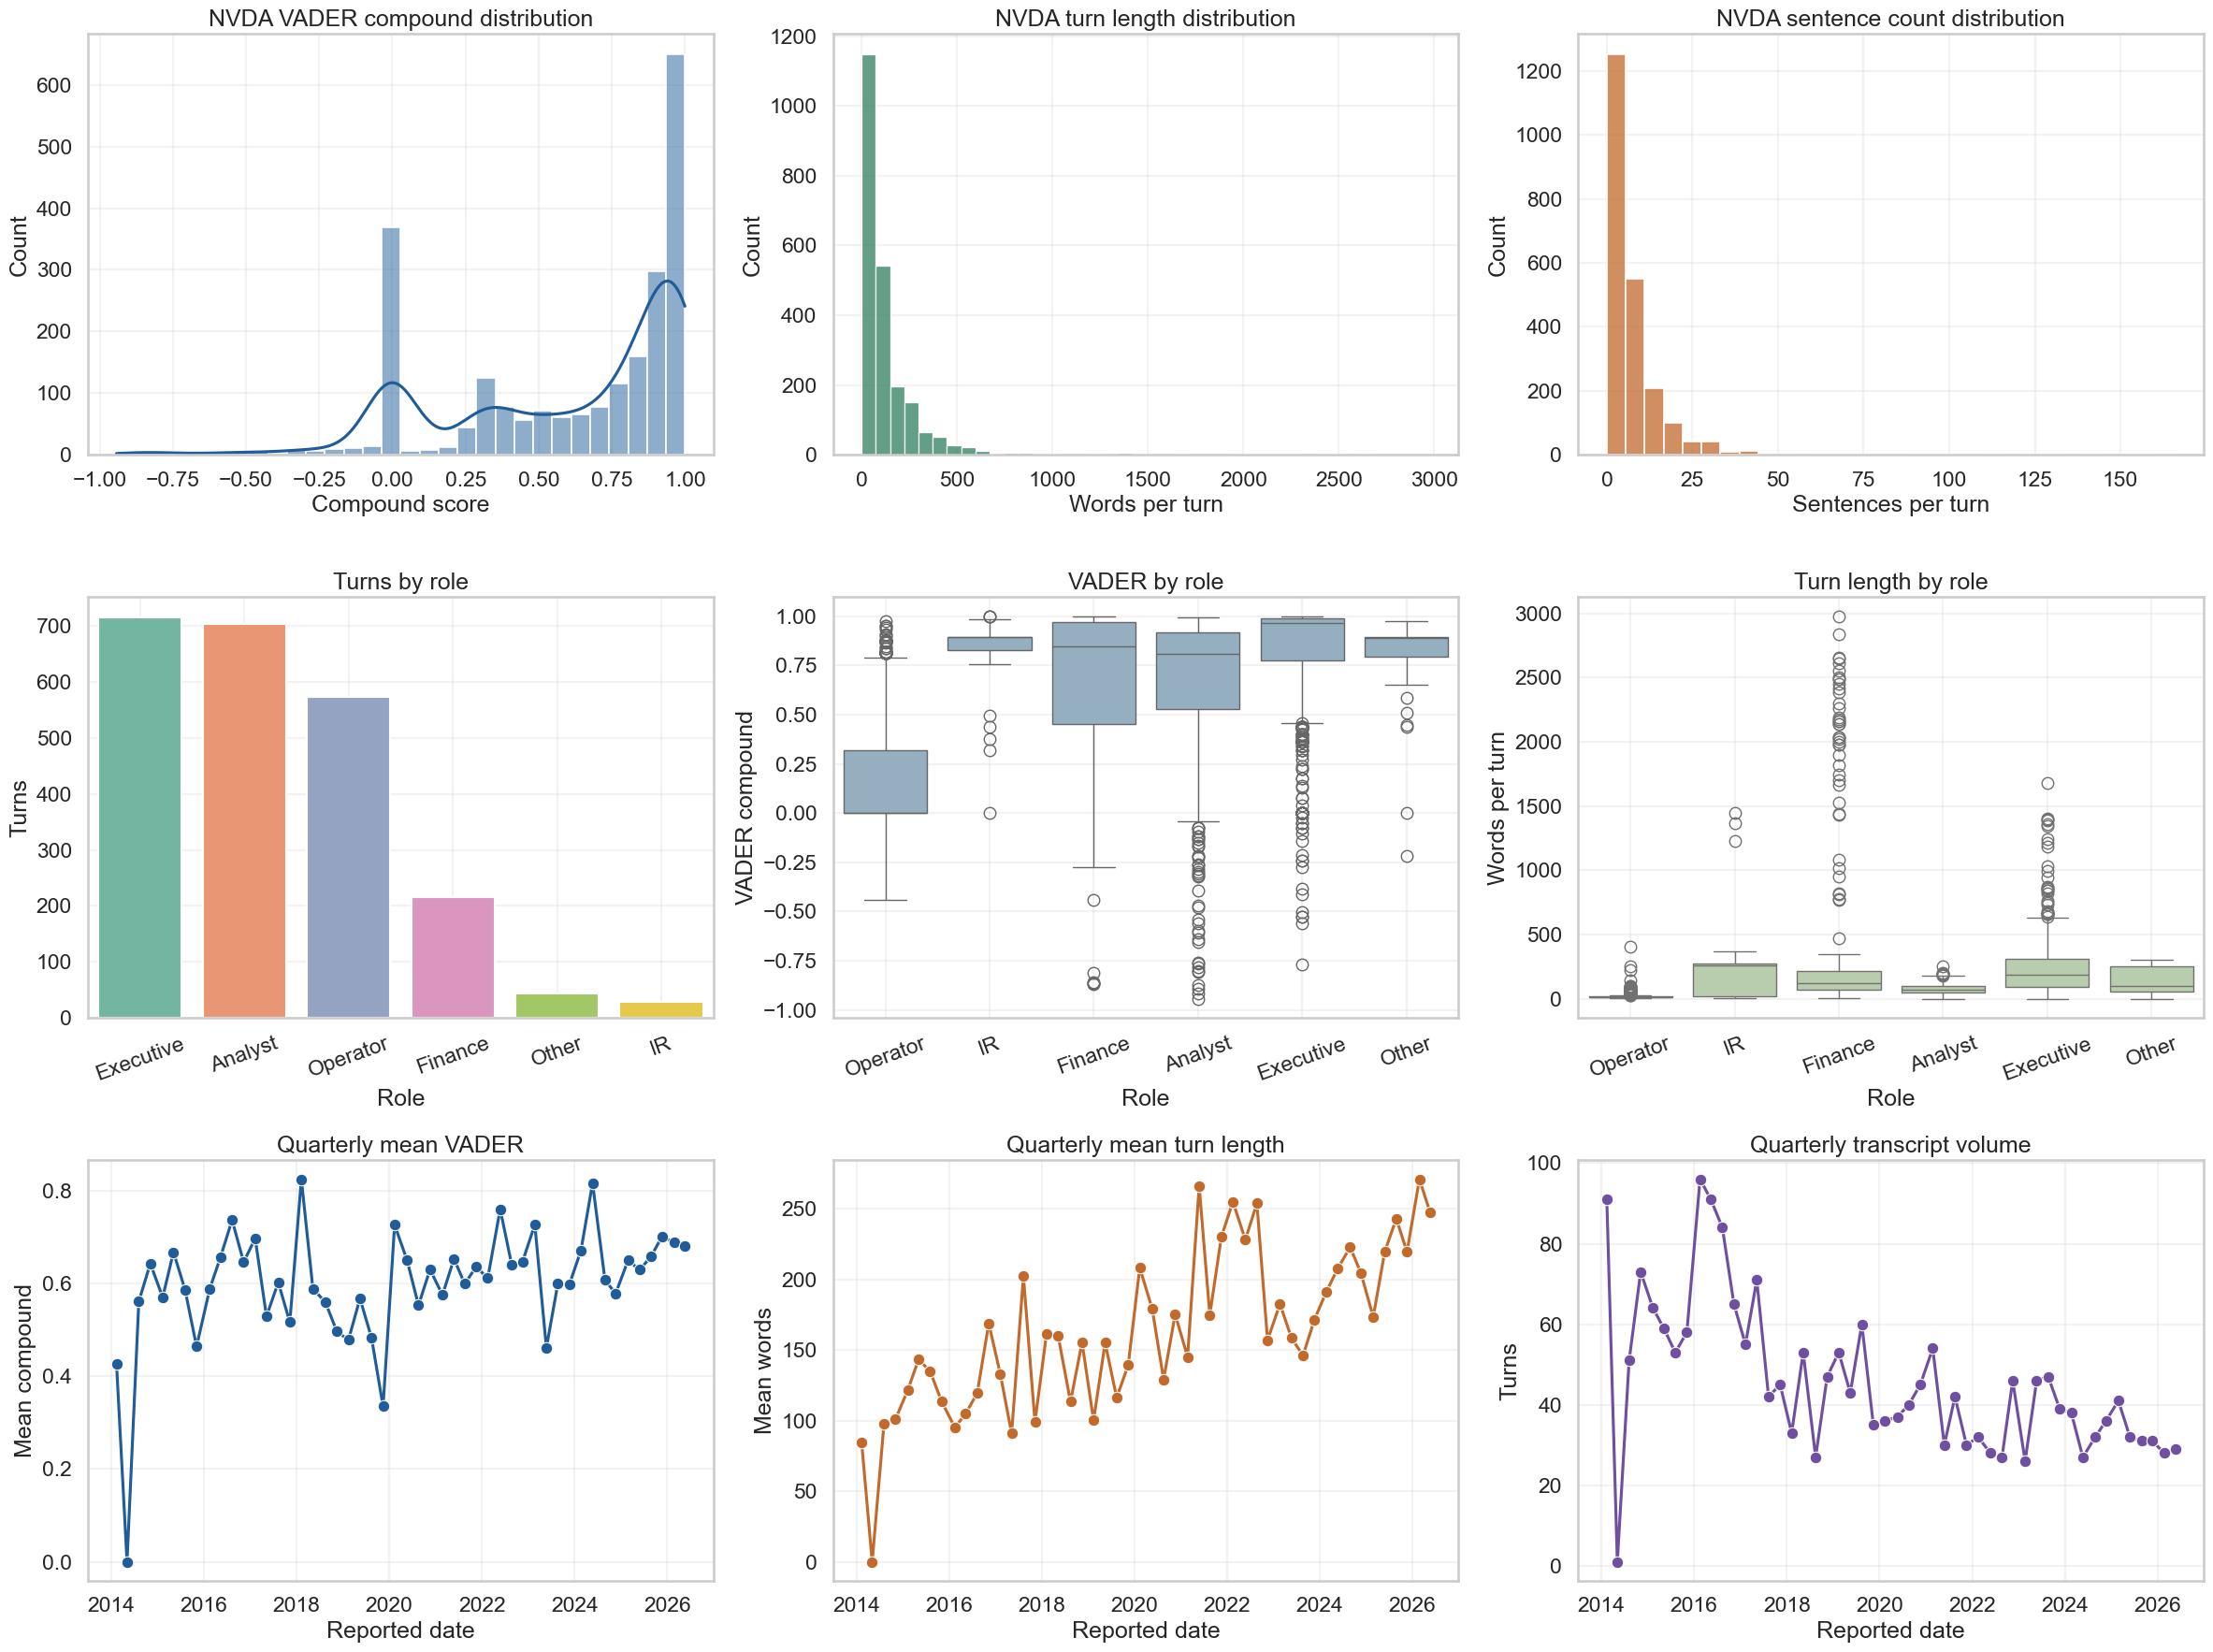

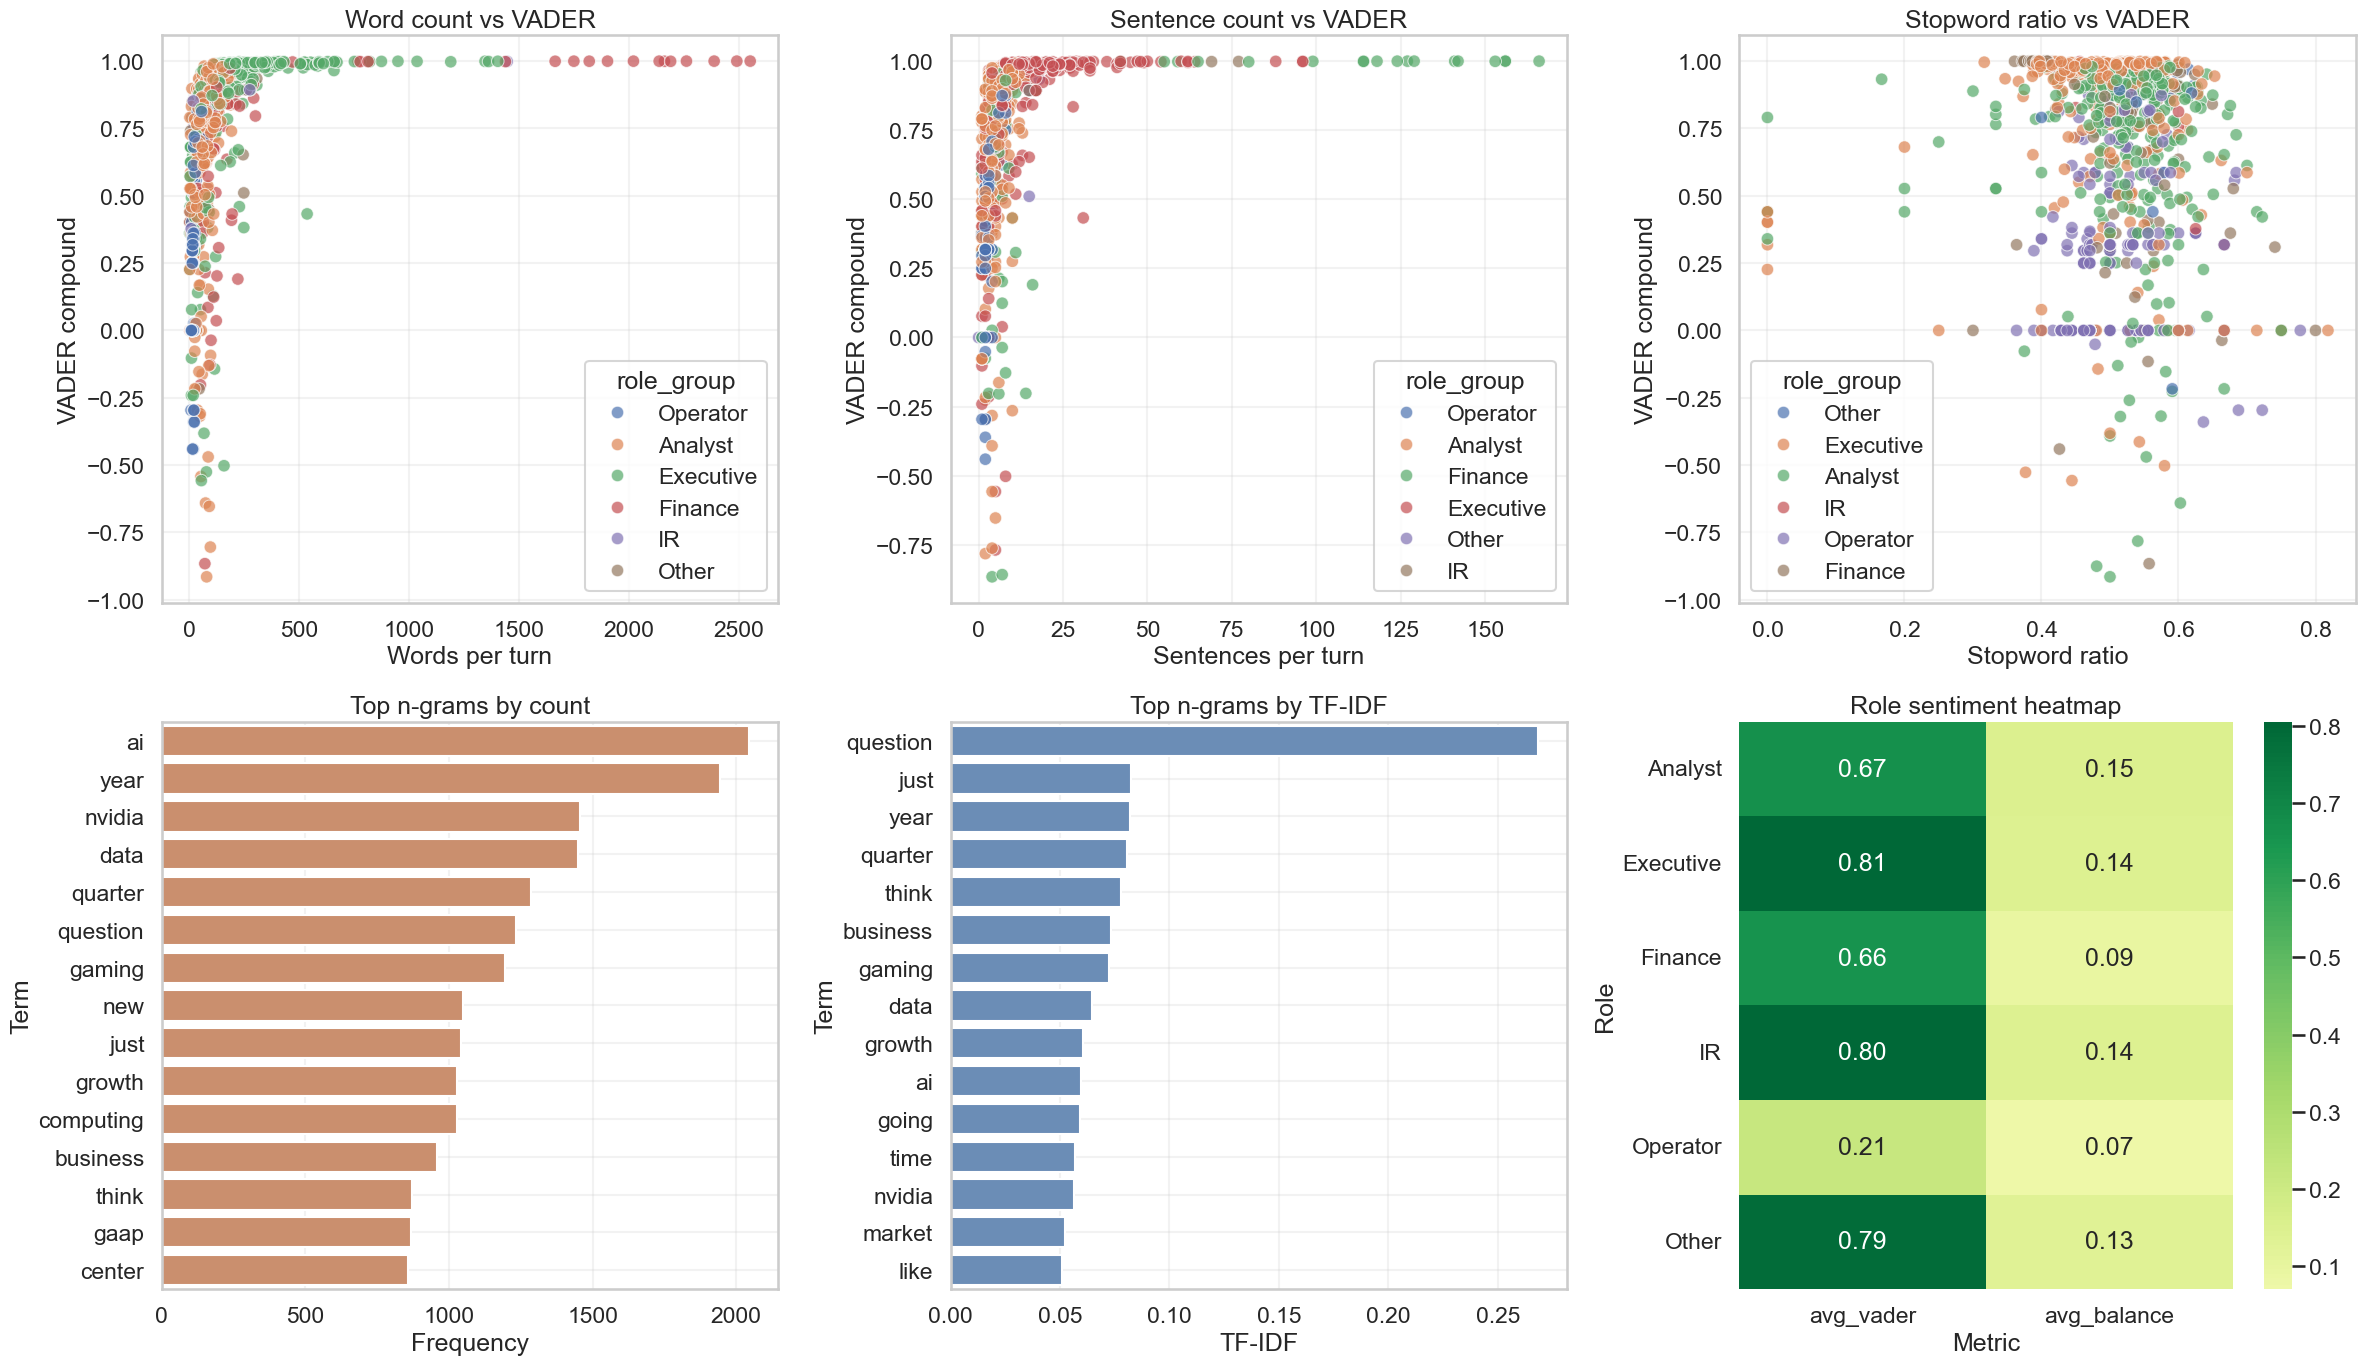

In [ ]:
import re

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)

focus_symbol = "NVDA"
data_path = "../ingestion/data/backup/temp_transcripts.parquet"


def classify_role(title: str, speaker: str) -> str:
    title_text = (title or "").lower()
    speaker_text = (speaker or "").lower()
    if speaker_text == "operator":
        return "Operator"
    if "analyst" in title_text or "research" in title_text:
        return "Analyst"
    if any(keyword in title_text for keyword in ["chief executive", "ceo", "president"]):
        return "Executive"
    if any(keyword in title_text for keyword in ["chief financial", "cfo", "finance"]):
        return "Finance"
    if any(keyword in title_text for keyword in ["investor relations", "ir"]):
        return "IR"
    return "Other"


def sentence_count(text: str) -> int:
    if not text:
        return 0
    pieces = re.split(r"[.!?]+", text)
    return sum(1 for piece in pieces if piece.strip())


def stopword_ratio(text: str) -> float:
    words = re.findall(r"[A-Za-z']+", (text or "").lower())
    if not words:
        return 0.0
    return sum(1 for word in words if word in ENGLISH_STOP_WORDS) / len(words)


def word_count(text: str) -> int:
    return len(re.findall(r"[A-Za-z']+", (text or "")))


nvda_raw = pl.read_parquet(data_path).filter(pl.col("symbol") == focus_symbol)

nvda_turns = (
    nvda_raw.select(
        [
            "fiscalDateEnding",
            "reportedDate",
            "reportTime",
            "symbol",
            "fiscal_month",
            "fiscal_year",
            "av_quarter",
            "time_from",
            pl.col("transcript"),
        ]
    )
    .explode("transcript")
    .unnest("transcript")
    .with_columns(
        [
            pl.col("speaker").fill_null("Unknown").str.strip_chars(),
            pl.col("title").fill_null("Unknown").str.strip_chars(),
            pl.col("content").fill_null("").str.strip_chars(),
            pl.col("sentiment").fill_null("Unknown").str.strip_chars(),
            pl.col("content").str.len_chars().alias("content_chars"),
            pl.col("content").str.count_matches(r"\S+").alias("content_words"),
            pl.struct(["title", "speaker"]).map_elements(
                lambda row: classify_role(row["title"], row["speaker"]),
                return_dtype=pl.String,
            ).alias("role_group"),
        ]
    )
)

print(f"{focus_symbol} quarter rows: {nvda_raw.height:,}")
print(f"{focus_symbol} transcript turns: {nvda_turns.height:,}")
print(f"Date range: {nvda_raw.select('reportedDate').min().item()} to {nvda_raw.select('reportedDate').max().item()}")
print(f"Avg turns per quarter: {nvda_turns.height / max(nvda_raw.height, 1):.1f}")
print(f"Quarters with empty transcripts: {nvda_raw.filter(pl.col('transcript').list.len() == 0).height:,}")

nvda_turns_pd = nvda_turns.select(
    ["reportedDate", "av_quarter", "reportTime", "speaker", "title", "role_group", "content", "content_words", "content_chars", "sentiment"]
).to_pandas()

analyzer = SentimentIntensityAnalyzer()
base_scores = nvda_turns_pd["content"].astype(str).map(analyzer.polarity_scores)
nvda_turns_pd["vader_compound"] = base_scores.map(lambda scores: scores["compound"])
nvda_turns_pd["vader_pos"] = base_scores.map(lambda scores: scores["pos"])
nvda_turns_pd["vader_neu"] = base_scores.map(lambda scores: scores["neu"])
nvda_turns_pd["vader_neg"] = base_scores.map(lambda scores: scores["neg"])
nvda_turns_pd["vader_label"] = pd.cut(
    nvda_turns_pd["vader_compound"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["negative", "neutral", "positive"],
)
nvda_turns_pd["vader_balance"] = nvda_turns_pd["vader_pos"] - nvda_turns_pd["vader_neg"]
nvda_turns_pd["sentence_count"] = nvda_turns_pd["content"].fillna("").astype(str).map(sentence_count)
nvda_turns_pd["stopword_ratio"] = nvda_turns_pd["content"].fillna("").astype(str).map(stopword_ratio)
nvda_turns_pd["word_count"] = nvda_turns_pd["content"].fillna("").astype(str).map(word_count)

quarter_summary = (
    nvda_turns_pd.groupby(["reportedDate", "av_quarter"], as_index=False)
    .agg(
        turns=("content", "size"),
        avg_vader=("vader_compound", "mean"),
        avg_balance=("vader_balance", "mean"),
        avg_words=("word_count", "mean"),
        avg_sentences=("sentence_count", "mean"),
    )
    .sort_values("reportedDate")
)

role_summary = (
    nvda_turns_pd.groupby("role_group", as_index=False)
    .agg(
        turns=("content", "size"),
        avg_vader=("vader_compound", "mean"),
        median_vader=("vader_compound", "median"),
        avg_words=("word_count", "mean"),
        avg_sentences=("sentence_count", "mean"),
        avg_stopword_ratio=("stopword_ratio", "mean"),
    )
    .sort_values("turns", ascending=False)
)

speaker_summary = (
    nvda_turns_pd.groupby("speaker", as_index=False)
    .agg(
        turns=("content", "size"),
        avg_vader=("vader_compound", "mean"),
        avg_words=("word_count", "mean"),
    )
    .sort_values("turns", ascending=False)
    .head(15)
)

print("Role summary")
display(role_summary)
print("Top speakers")
display(speaker_summary)

sample_source = nvda_turns_pd.loc[nvda_turns_pd["word_count"] > 0, ["content", "role_group"]].copy()
sample_df = sample_source.sample(n=min(4000, len(sample_source)), random_state=42).copy()

sample_df["sentence_count"] = sample_df["content"].map(sentence_count)
sample_df["stopword_ratio"] = sample_df["content"].map(stopword_ratio)
sample_df["word_count"] = sample_df["content"].map(word_count)
sample_df["char_count"] = sample_df["content"].str.len()

count_vectorizer = CountVectorizer(stop_words="english", max_features=30, ngram_range=(1, 2), min_df=2)
term_matrix = count_vectorizer.fit_transform(sample_df["content"].astype(str).tolist())
term_counts = term_matrix.sum(axis=0).A1
term_frame = pd.DataFrame({"term": count_vectorizer.get_feature_names_out(), "frequency": term_counts}).sort_values("frequency", ascending=False)

tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=30, ngram_range=(1, 2), min_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_df["content"].astype(str).tolist())
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
tfidf_frame = pd.DataFrame({"term": tfidf_vectorizer.get_feature_names_out(), "tfidf": tfidf_scores}).sort_values("tfidf", ascending=False)

role_plot = role_summary.copy()
role_plot["role_group"] = pd.Categorical(role_plot["role_group"], categories=role_plot["role_group"].tolist(), ordered=True)

fig, axes = plt.subplots(3, 3, figsize=(24, 18))

sns.histplot(nvda_turns_pd["vader_compound"], bins=30, kde=True, ax=axes[0, 0], color="#1f5c99")
axes[0, 0].set_title(f"{focus_symbol} VADER compound distribution")
axes[0, 0].set_xlabel("Compound score")

sns.histplot(nvda_turns_pd["word_count"], bins=40, ax=axes[0, 1], color="#2f7f5f")
axes[0, 1].set_title(f"{focus_symbol} turn length distribution")
axes[0, 1].set_xlabel("Words per turn")

sns.histplot(nvda_turns_pd["sentence_count"], bins=30, ax=axes[0, 2], color="#c26a2c")
axes[0, 2].set_title(f"{focus_symbol} sentence count distribution")
axes[0, 2].set_xlabel("Sentences per turn")

sns.barplot(data=role_plot, x="role_group", y="turns", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Turns by role")
axes[1, 0].set_xlabel("Role")
axes[1, 0].set_ylabel("Turns")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.boxplot(data=nvda_turns_pd, x="role_group", y="vader_compound", ax=axes[1, 1], color="#8eb1c7")
axes[1, 1].set_title("VADER by role")
axes[1, 1].set_xlabel("Role")
axes[1, 1].set_ylabel("VADER compound")
axes[1, 1].tick_params(axis="x", rotation=20)

sns.boxplot(data=nvda_turns_pd, x="role_group", y="word_count", ax=axes[1, 2], color="#b6d2a8")
axes[1, 2].set_title("Turn length by role")
axes[1, 2].set_xlabel("Role")
axes[1, 2].set_ylabel("Words per turn")
axes[1, 2].tick_params(axis="x", rotation=20)

sns.lineplot(data=quarter_summary, x="reportedDate", y="avg_vader", marker="o", ax=axes[2, 0], color="#1f5c99")
axes[2, 0].set_title("Quarterly mean VADER")
axes[2, 0].set_xlabel("Reported date")
axes[2, 0].set_ylabel("Mean compound")

sns.lineplot(data=quarter_summary, x="reportedDate", y="avg_words", marker="o", ax=axes[2, 1], color="#c26a2c")
axes[2, 1].set_title("Quarterly mean turn length")
axes[2, 1].set_xlabel("Reported date")
axes[2, 1].set_ylabel("Mean words")

sns.lineplot(data=quarter_summary, x="reportedDate", y="turns", marker="o", ax=axes[2, 2], color="#6f4f9f")
axes[2, 2].set_title("Quarterly transcript volume")
axes[2, 2].set_xlabel("Reported date")
axes[2, 2].set_ylabel("Turns")

for axis in axes.flat:
    axis.grid(True, alpha=0.25)

plt.tight_layout()

fig2, axes2 = plt.subplots(2, 3, figsize=(24, 14))

sns.scatterplot(data=nvda_turns_pd.sample(n=min(1000, len(nvda_turns_pd)), random_state=7), x="word_count", y="vader_compound", hue="role_group", alpha=0.7, ax=axes2[0, 0])
axes2[0, 0].set_title("Word count vs VADER")
axes2[0, 0].set_xlabel("Words per turn")
axes2[0, 0].set_ylabel("VADER compound")

sns.scatterplot(data=nvda_turns_pd.sample(n=min(1000, len(nvda_turns_pd)), random_state=11), x="sentence_count", y="vader_compound", hue="role_group", alpha=0.7, ax=axes2[0, 1])
axes2[0, 1].set_title("Sentence count vs VADER")
axes2[0, 1].set_xlabel("Sentences per turn")
axes2[0, 1].set_ylabel("VADER compound")

sns.scatterplot(data=nvda_turns_pd.sample(n=min(1000, len(nvda_turns_pd)), random_state=13), x="stopword_ratio", y="vader_compound", hue="role_group", alpha=0.7, ax=axes2[0, 2])
axes2[0, 2].set_title("Stopword ratio vs VADER")
axes2[0, 2].set_xlabel("Stopword ratio")
axes2[0, 2].set_ylabel("VADER compound")

sns.barplot(data=term_frame.head(15), x="frequency", y="term", ax=axes2[1, 0], color="#d98b5f")
axes2[1, 0].set_title("Top n-grams by count")
axes2[1, 0].set_xlabel("Frequency")
axes2[1, 0].set_ylabel("Term")

sns.barplot(data=tfidf_frame.head(15), x="tfidf", y="term", ax=axes2[1, 1], color="#5f8cc2")
axes2[1, 1].set_title("Top n-grams by TF-IDF")
axes2[1, 1].set_xlabel("TF-IDF")
axes2[1, 1].set_ylabel("Term")

role_sentiment = (
    nvda_turns_pd.groupby("role_group", as_index=False)
    .agg(avg_vader=("vader_compound", "mean"), avg_balance=("vader_balance", "mean"))
)
sns.heatmap(
    role_sentiment.set_index("role_group"),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes2[1, 2],
    cbar=True,
)
axes2[1, 2].set_title("Role sentiment heatmap")
axes2[1, 2].set_xlabel("Metric")
axes2[1, 2].set_ylabel("Role")

for axis in axes2.flat:
    axis.grid(True, alpha=0.25)

plt.tight_layout()

print("Most positive turns")
display(nvda_turns_pd.nlargest(8, "vader_compound")[['reportedDate', 'av_quarter', 'speaker', 'role_group', 'word_count', 'vader_compound', 'content']])
print("Most negative turns")
display(nvda_turns_pd.nsmallest(8, "vader_compound")[['reportedDate', 'av_quarter', 'speaker', 'role_group', 'word_count', 'vader_compound', 'content']])